In [1]:
import sys, os
import yaml
import torch
from tqdm import tqdm
import numpy as np
import pickle
import matplotlib.pyplot as plt

sys.path.append(os.path.join(os.getcwd(), ".."))
from models.recurrentPPO import environment, RecurrentPPO
from models.experiment_model import StateSpaceModel

In [ ]:
with open(r"..\config\recurrentPPO.yaml") as f:
    config = yaml.safe_load(f)

network_arg = config["network_arg"]
lr = config["lr"]
update_arg = config["update_arg"]
max_speed = config["pum_max_speed"]

MAX_EPISODE = 75000
MAX_TIME_PER_EPISODE = 60*15
DT = 3
MAX_ITER_PER_EPISODE = int(MAX_TIME_PER_EPISODE/DT)
UPDATE_N = 2048

if UPDATE_N % update_arg["batch_size"] == 0:
    pass
else:
    raise ValueError(f"Step for update ({UPDATE_N}) is not divisible by batch size ({update_arg["batch_size"]})")

In [3]:
config

{'controller_mode': 'RL',
 'controller_type': 'RecurrentPPO',
 'UPPER_VALVE_PIN': 5,
 'LOWER_VALVE_PIN': 6,
 'PUMP_PIN': 4,
 'network_arg': {'input_dim': 2,
  'enc_hidden_dim': 128,
  'enc_layer_num': 2,
  'lstm_hidden_dim': 128,
  'lstm_num_layers': 1,
  'head_hidden_dim': 64,
  'head_layer_num': 2,
  'action_output_dim': 2,
  'value_output_dim': 1},
 'lr': {'common': 0.0001, 'critic': 0.0003, 'actor': 0.0001},
 'pum_max_speed': 36.0,
 'update_arg': {'GAMMA': 0.99,
  'LAMBDA': 0.95,
  'epoches': 16,
  'batch_size': 8,
  'epsilon': 0.2,
  'beta': 0.01}}

In [4]:
agent = RecurrentPPO(network_arg, lr, max_speed)
print(agent.network)

LSTMBodyNetwork(
  (encoder): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
  )
  (lstm): LSTM(128, 128, batch_first=True)
  (actor): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
  (critic): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [5]:
def evaluate(agent, num_episodes=10):
    eval_env = environment()
    total_rewards = []

    agent.network.eval()

    for ep in range(num_episodes):
        state = eval_env.reset()
        episode_reward = 0

        for _ in range(MAX_ITER_PER_EPISODE):
            with torch.no_grad():
                action = agent.deterministic_action(state)
            next_state, reward, terminated = eval_env.step(action, dt=DT)

            episode_reward += reward
            state = next_state

            if terminated:
                break

        total_rewards.append(episode_reward)

    agent.network.train()
    
    return total_rewards

In [6]:
n = 0
env = environment()
eval_episodes = []
eval_means    = []
eval_stds     = []

beta_initial = 1
beta_final = update_arg["beta"]

for ep in tqdm(range(MAX_EPISODE)):
    state = env.reset()
    agent.reset_hidden()
    done = False
    
    for _ in range(MAX_ITER_PER_EPISODE):  # ← replaces while not done
        action, value = agent.distributional_action(state)
        next_state, reward, terminated = env.step(action, dt=DT)
        agent.store_transition(state, action, reward, next_state, terminated)

        n += 1
        if n % UPDATE_N == 0:
            beta_coef = beta_initial * (beta_final / beta_initial) ** (ep / MAX_EPISODE)
            agent.update(update_arg["GAMMA"], update_arg["LAMBDA"], update_arg["epoches"], update_arg["batch_size"], update_arg["epsilon"], beta_coef)

            if (n // UPDATE_N) % 5 == 0:
                rewards = evaluate(agent)
                eval_episodes.append(ep)
                eval_means.append(np.mean(rewards))
                eval_stds.append(np.std(rewards))

        state = next_state
        if terminated:
            break

100%|██████████| 75000/75000 [14:33:27<00:00,  1.43it/s]   


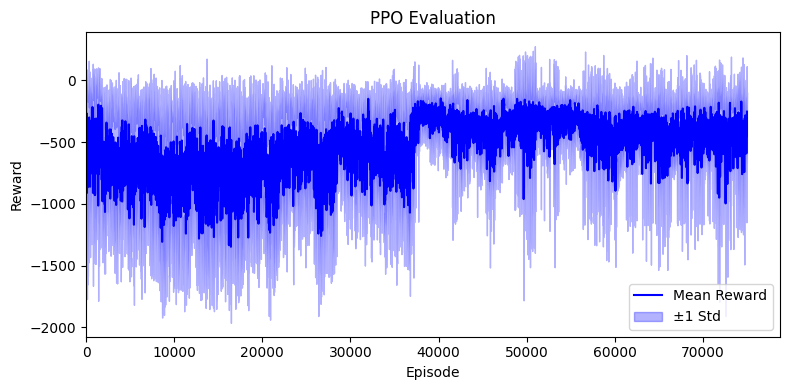

In [7]:
means = np.array(eval_means)
stds  = np.array(eval_stds)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(eval_episodes, means, color="blue", label="Mean Reward")
ax.fill_between(eval_episodes, means - stds, means + stds, alpha=0.3, color="blue", label="±1 Std")
ax.set_xlabel("Episode")
ax.set_ylabel("Reward")
ax.set_xlim(left=0)
ax.set_title("PPO Evaluation")
ax.legend()
plt.tight_layout()
plt.show()

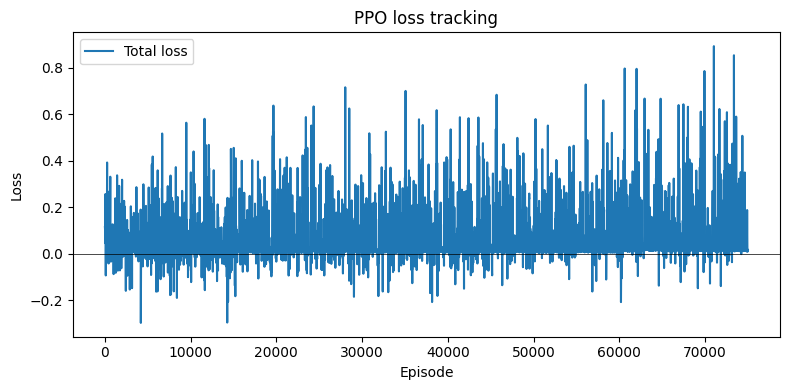

In [8]:
tot_loss = np.array(agent.tot_loss_history)
actor_loss = np.array(agent.actor_loss_history)
critic_loss = np.array(agent.critic_loss_history)
entropy_loss = np.array(agent.entropy_loss_history)

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(eval_episodes, tot_loss, label="Total loss")
ax.set_xlabel("Episode")
ax.set_ylabel("Loss")
ax.set_title("PPO loss tracking")
ax.legend()
ax.axhline(y=0, color="k", lw=0.5)
plt.tight_layout()
plt.show()

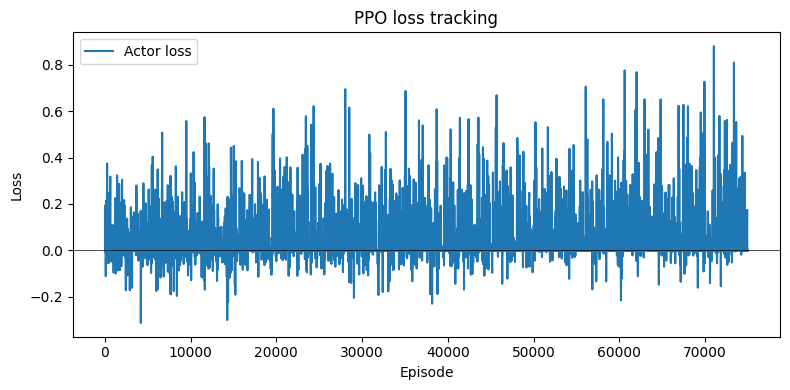

In [9]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(eval_episodes, actor_loss, label="Actor loss")
ax.set_xlabel("Episode")
ax.set_ylabel("Loss")
ax.set_title("PPO loss tracking")
ax.legend()
ax.axhline(y=0, color="k", lw=0.5)
plt.tight_layout()
plt.show()

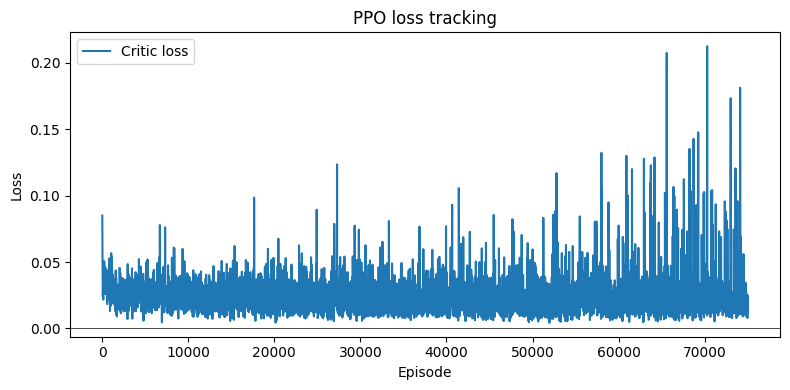

In [10]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(eval_episodes, critic_loss, label="Critic loss")
ax.set_xlabel("Episode")
ax.set_ylabel("Loss")
ax.set_title("PPO loss tracking")
ax.legend()
ax.axhline(y=0, color="k", lw=0.5)
plt.tight_layout()
plt.show()

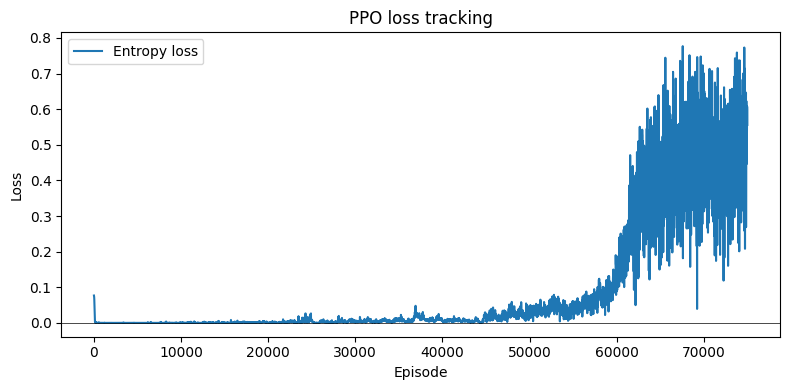

In [11]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(eval_episodes, entropy_loss, label="Entropy loss")
ax.set_xlabel("Episode")
ax.set_ylabel("Loss")
ax.set_title("PPO loss tracking")
ax.legend()
ax.axhline(y=0, color="k", lw=0.5)
plt.tight_layout()
plt.show()

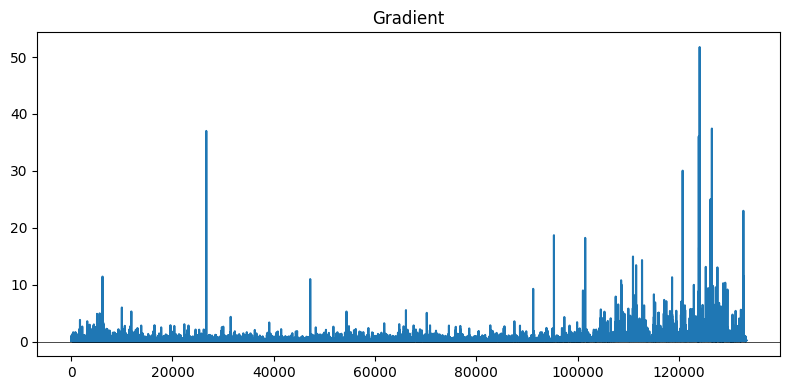

In [12]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(agent.gradient_history)
ax.axhline(y=0, color="k", lw=0.5)
ax.set_title("Gradient")
plt.tight_layout()
plt.show()

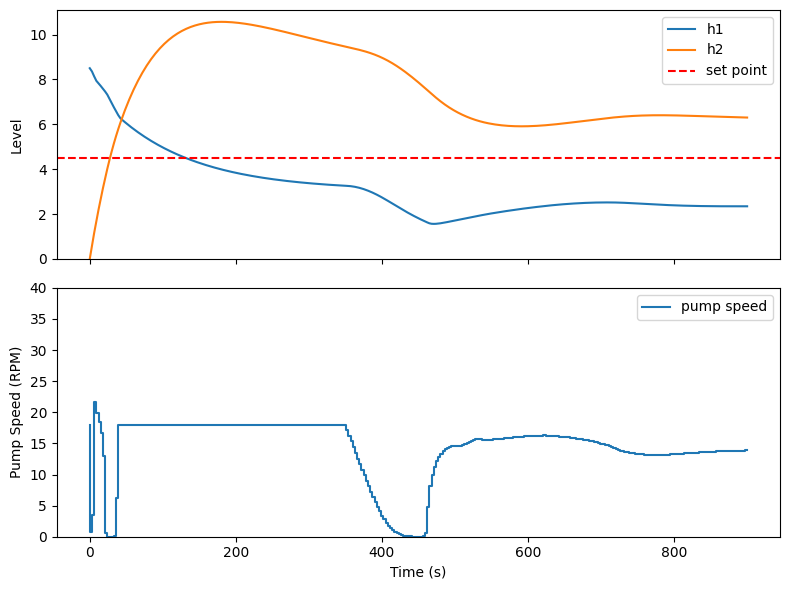

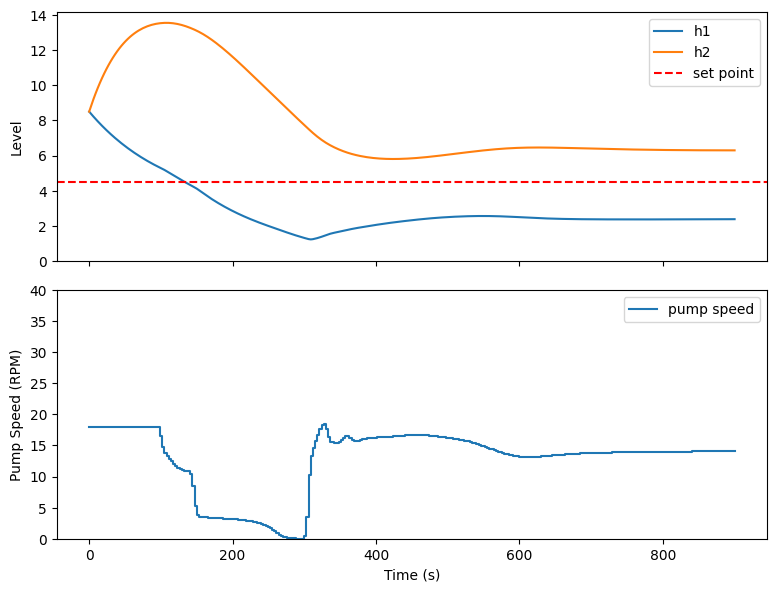

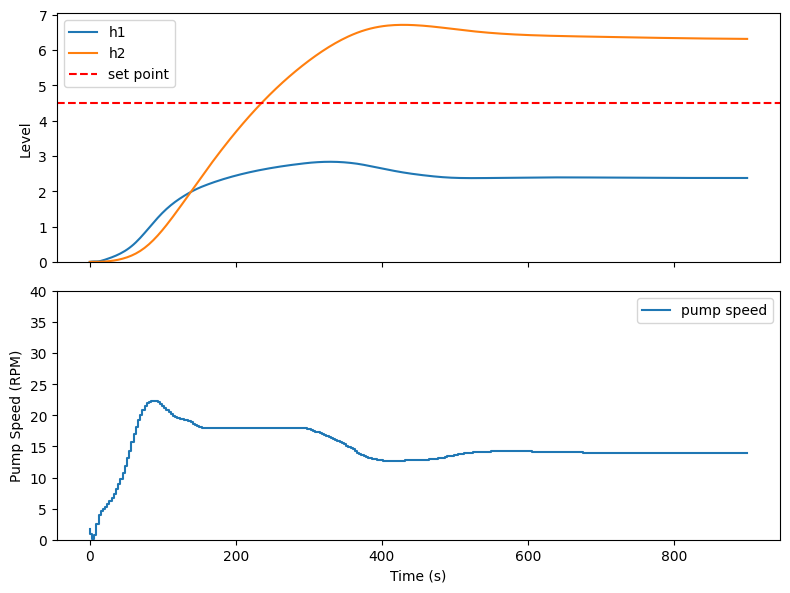

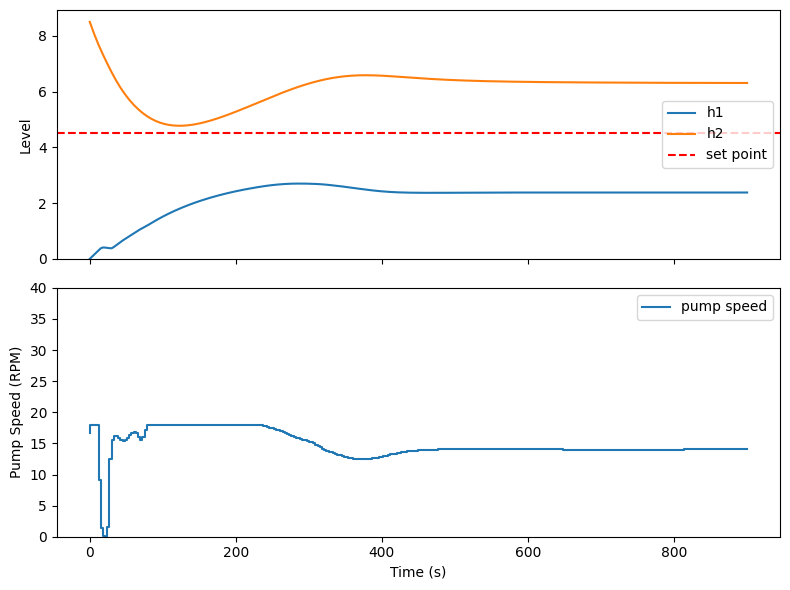

In [13]:
SET_POINT = 4.5
MAX_H = 8.5
INITIAL_STATE = np.array([[8.5, 8.5, 0, 0], 
                          [0, 8.5, 0, 8.5]])

agent.network.eval()

with open(r"..\parameters\state_space_param.pickle", "rb") as f:
    param = pickle.load(f)
A, B, C, D = param["A"], param["B"], param["C"], param["D"]

environment = StateSpaceModel(pred_x0=False)

with torch.no_grad():
    for i in range(INITIAL_STATE.shape[1]):
        h1_trajectory = []
        h2_trajectory = []
        action_trajectory = []
        time_trajectory = []
        xk = INITIAL_STATE[:,i]
        h1_trajectory.append(xk[0].item())
        h2_trajectory.append(xk[1].item())
        for j in range(MAX_ITER_PER_EPISODE):
            input_state = np.array((xk[1].item(), SET_POINT))
            norm_state = input_state/MAX_H
            action = agent.deterministic_action(norm_state)
            action_trajectory.append(action)
            time_trajectory.append(j*DT)
            xk, _ = environment.step_pred(A, B, C, D, xk, action, dt=DT)
            h1_trajectory.append(xk[0].item())
            h2_trajectory.append(xk[1].item())
        time_trajectory.append((j+1)*DT)
        input_state = np.array((xk[1].item(), SET_POINT))
        norm_state = input_state/MAX_H
        action = agent.deterministic_action(norm_state)
        action_trajectory.append(action)

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

        ax1.plot(time_trajectory, h1_trajectory, label="h1")
        ax1.plot(time_trajectory, h2_trajectory, label="h2")
        ax1.axhline(y=SET_POINT, label="set point", ls="--", color="red")  # cleaner for constant lines
        ax1.set_ylabel("Level")
        ax1.set_ylim(bottom=0)
        ax1.legend()

        ax2.step(time_trajectory, action_trajectory, label="pump speed")
        ax2.set_ylabel("Pump Speed (RPM)")
        ax2.set_xlabel("Time (s)")
        ax2.set_ylim(bottom=0, top=40)
        ax2.legend()

        plt.tight_layout()
        plt.show()

In [ ]:
"""torch.save(agent.network.state_dict(), r"..\parameters\recurrentPPO.pt")"""